Exploratory data analysis of salary trends, companies, experience levels, and compensation using Python and Pandas.

Tools: Python, Pandas, NumPy, Matplotlib, Seaborn

Author: Aida Badenova | nFactorial School

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats 

# Описание полей

- `timestamp` -- дата и время поста 
<br>
- `company` -- название компании
<br>
- `level` -- уровень специалиста (jun - mid - senior etc)
<br>
- `title` -- название вакансии 
<br>
- `totalyearlycompensation` -- годовая заработная плана. в контексте всех последующих задач, именно это поле будет иметься в виду под названием "зарплата"
<br>
- `location` -- город и штат\страна, где работает специалист
<br>
- `yearsofexperience` -- уровень специалиста
<br>
- `yearsatcompany` -- опыт работы специалиста 
<br>
- `basesalary` -- базовая компенсация
<br>



In [2]:
df = pd.read_excel('P01_Salaries_Dataset.xlsx', index_col = 0)

Вам необходимо будет проделать несколько задач по датасету, в удобном для вас формате -- либо используя **методы pandas**, либо **через SQL-код**

# Задачи

1. Сколько уникальных компаний находятся в топ 10 по сумме годовых заработной платы `totalyearlycompensation`?
1. Какой средний опыт работы у `Software Engineers` в компании `Oracle` с заработной платой больше `50.000`?
1. Каковы средние зарплаты по локациям `Austin, TX`, `London, EN, United Kingdom` и `Redmond, WA`
1. Какова средняя зарплата в целом в штате Калифорния? `(CA)`

1. Сравните заработные платы компаний "FAANG" против остальных компаний в разрезе позиции `Software Engineer`

1. Сравните среднюю, медиану и моду по заработным платам у `Software Engineers` за периоды 
  `январь 2021 - апрель 2021`  vs `май 2021 - август 2021` (включительно)
1. Визуализируйте данные с предыдущего задания линейным графиком, где должны быть соблюдены следующие условия:
    - Период январь-апрель должен быть зеленого цвета
    - Период май-август должен быть красного цвета
    - на линейном графике должны присутствовать только средние значения (mean)

1. Оцените влияние уровня образования (или его отсутствия) к заработной плате

1. Оцените _зависимость_ между опытом работы `yearsofexperience` и заработной платой

1. Сделайте сравнение уровня зарплат в зависимости от грэйда (level) в компании Amazon на позицию 'Software Engineer'. Постройте визуализацию и **напишите ваши выводы**. [Подробнее о грэйдах в Amazon](https://careerkarma.com/blog/software-engineering-salary-amazon/), [примеры исследования позиций и зарплат в Казахстане](https://zerttey.kolesa.group/datascience#zp)

1. Сколько уникальных компаний находятся в топ 10 по сумме годовых заработной платы `totalyearlycompensation`?


In [8]:
top10 = (
df.groupby('company')['totalyearlycompensation'].sum() # собрали все строки по каждой компании и посчитали сумму зарплат
.sort_values(ascending=False) # от самой большой суммы к меньшей
.head(10) # только первые 10 компаний
)
top10

company
Amazon        2068283500
Google        1370357000
Microsoft     1209223906
Facebook      1141906500
Apple          636450500
Salesforce     310450500
Uber           303198000
Oracle         271140500
LinkedIn       241378000
Cisco          198410000
Name: totalyearlycompensation, dtype: int64

In [10]:
top10_df = top10.reset_index()
top10_df.columns = ['company', 'total_compensation']
top10_df.index = top10_df.index + 1
top10_df

,company,total_compensation
1,Amazon,2068283500
2,Google,1370357000
3,Microsoft,1209223906
4,Facebook,1141906500
5,Apple,636450500
6,Salesforce,310450500
7,Uber,303198000
8,Oracle,271140500
9,LinkedIn,241378000
10,Cisco,198410000


2. Какой средний опыт работы у `Software Engineers` в компании `Oracle` с заработной платой больше `50.000`?


In [16]:
filtered_df = df[
    (df['company'] == 'Oracle') & 
    (df ['title'] == "Software Engineer") &
    (df ['totalyearlycompensation'] > 50000) # отфильтровали нужные строки
     
]
filtered_df.head()

,timestamp,company,level,title,totalyearlycompensation,location,yearsofexperience,yearsatcompany,tag,basesalary,stockgrantvalue,bonus,gender,Race,Education
159,2018-02-09 00:53:11,Oracle,Ic5,Software Engineer,320000,"Seattle, WA",10.0,2.0,NaN,0,0.0,0.0,NaN,NaN,NaN
205,2018-03-08 05:19:00,Oracle,IC4,Software Engineer,300000,"Seattle, WA",10.0,1.0,NaN,0,0.0,0.0,NaN,NaN,NaN
274,2018-04-17 00:26:06,Oracle,IC-4,Software Engineer,128000,"Santa Clara, CA",9.0,3.0,NaN,123000,5000.0,0.0,Male,NaN,NaN
297,2018-04-27 16:36:18,Oracle,IC4,Software Engineer,320000,"Seattle, WA",14.0,1.0,NaN,0,0.0,0.0,NaN,NaN,NaN
358,2018-05-17 12:47:30,Oracle,IC4,Software Engineer,300000,"Seattle, WA",19.0,1.0,NaN,185000,115000.0,0.0,Male,NaN,NaN


In [17]:
mean_experience = filtered_df['yearsofexperience'].mean ()
mean_experience

np.float64(7.959697732997481)

In [18]:
print ('Средний опыт:', round(mean_experience,2))

Средний опыт: 7.96


3. Каковы средние зарплаты по локациям `Austin, TX`, `London, EN, United Kingdom` и `Redmond, WA`?


In [ ]:
locations = ['Austin, TX', 'London, EN, United Kingdom', 'Redmond, WA'] # создаем список локаций, согласно заданию
avg_salary_by_location = (
    df[df['location'].isin (locations)] # берем из всей таблицы локации смотрим есть ли они в нашем списке
    .groupby('location')['totalyearlycompensation'] # группируем по локациям и для каждой локации считаем среднюю зп 
    .mean() # считаем среднюю зп
    .sort_values(ascending = False) # сортируем средние зп по убыванию, сначала самая высокая, потом ниже 
    .reset_index() # превращаем результат из сириес в датафрейм
)
avg_salary_by_location.columns = ['location','avg_salary'] # переименовываем названия колонок в более понятные 

avg_salary_by_location

,location,avg_salary
0,"Redmond, WA",225076.573072
1,"Austin, TX",179809.164733
2,"London, EN, United Kingdom",171934.554974


4. Какова средняя зарплата в целом в штате Калифорния? `(CA)`



In [25]:
ca_avg_salary = df[
    df['location'].str.contains (', CA', na=False) # оставляем только те строки где есть Калифорния штат 
    ]['totalyearlycompensation'].mean() # берем колонку зп и считаем ее среднюю

ca_avg_salary

np.float64(271834.7212947323)

5. Сравните заработные платы компаний "FAANG" против остальных компаний в разрезе позиции `Software Engineer`



In [ ]:
faang = ['Facebook', 'Apple', 'Amazon', 'Netflix', 'Google']
se_df = df[df['title'] == 'Software Engineer'].copy() # .copy() нужен, чтобы избежать ошибки SettingWithCopyWarning
se_df['company_group'] = se_df['company'].apply(lambda x: 'FAANG' if x in faang else 'Other')
result = (
    se_df
    .groupby ('company_group')['totalyearlycompensation']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
    )
result 

,count,mean,median
company_group,,,
FAANG,12820,255887.402496,226000.0
Other,33355,186222.725408,165000.0


6. Сравните среднюю, медиану и моду по заработным платам у `Software Engineers` за периоды 
  `январь 2021 - апрель 2021`  vs `май 2021 - август 2021` (включительно)


In [ ]:
import pandas as pd # мне пришлось  заново загрузить данные, так как в этом моменте у меня перезапустился сам по себе компьютер, df не распознал и вышла ошибка
df = pd.read_excel('P01_Salaries_Dataset.xlsx')

In [ ]:
df['timestamp'] = pd.to_datetime (df['timestamp']) # преобразуем колонку timestamp в формат даты, без этого питон воспринимает даты как текст (строки) и сравнение по датам работать не будет
df.head()

,Unnamed: 0,timestamp,company,level,title,totalyearlycompensation,location,yearsofexperience,yearsatcompany,tag,basesalary,stockgrantvalue,bonus,gender,Race,Education
0,0,2017-06-07 11:33:27,Oracle,L3,Product Manager,127000,"Redwood City, CA",1.5,1.5,NaN,107000,20000.0,10000.0,NaN,NaN,NaN
1,1,2017-06-10 17:11:29,eBay,SE 2,Software Engineer,100000,"San Francisco, CA",5.0,3.0,NaN,0,0.0,0.0,NaN,NaN,NaN
2,2,2017-06-11 14:53:57,Amazon,L7,Product Manager,310000,"Seattle, WA",8.0,0.0,NaN,155000,0.0,0.0,NaN,NaN,NaN
3,3,2017-06-17 00:23:14,Apple,M1,Software Engineering Manager,372000,"Sunnyvale, CA",7.0,5.0,NaN,157000,180000.0,35000.0,NaN,NaN,NaN
4,4,2017-06-20 10:58:51,Microsoft,60,Software Engineer,157000,"Mountain View, CA",5.0,3.0,NaN,0,0.0,0.0,NaN,NaN,NaN


In [ ]:
se_2021 = df[ # фильтрация. фильтруем данные 
    (df['title'] == 'Software Engineer') & # только эту должность
    (df ['timestamp'] >='2021-01-01') & # с января 2021  
    (df['timestamp'] < '2021-09-01')  # до сентября (не включая)
    ].copy() # создаем копию, чтобы избежать ошибок в пандасе
se_2021.head()

,Unnamed: 0,timestamp,company,level,title,totalyearlycompensation,location,yearsofexperience,yearsatcompany,tag,basesalary,stockgrantvalue,bonus,gender,Race,Education
38422,38422,2021-01-01 01:03:27,Amazon,L5,Software Engineer,238000,"Seattle, WA",3.0,0.0,Web Development (Front-End),160000,44000.0,34000.0,Male,Black,Bachelor's Degree
38423,38423,2021-01-01 01:43:23,Western Digital,L1,Software Engineer,21000,"Bangalore, KA, India",3.0,3.0,Testing (SDET),19000,0.0,2000.0,Male,NaN,Bachelor's Degree
38425,38425,2021-01-01 02:35:37,Jane Street,Summer Analyst,Software Engineer,288000,"Hong Kong, HK, Hong Kong (SAR)",0.0,0.0,Security,288000,0.0,0.0,Male,Asian,Bachelor's Degree
38427,38427,2021-01-01 03:25:34,Google,L6,Software Engineer,228000,"Sydney, NS, Australia",14.0,7.0,Site Reliability (SRE),157000,28000.0,44000.0,Male,NaN,Master's Degree
38429,38429,2021-01-01 05:56:40,Stripe,L3,Software Engineer,371000,"Dublin, DN, Ireland",7.0,1.0,Full Stack,148000,200000.0,23000.0,Male,NaN,Bachelor's Degree


In [ ]:
se_2021['period'] = se_2021['timestamp'].apply( # работа с датами. делим на группы. создаем новую колонку period для того чтобы разделить все строки на два периода: янв-апр и май-авг
    lambda x: 'Jan-Apr' if x < pd.Timestamp ('2021-05-01') else 'May-Aug' # для каждой даты проверяем если дата раньше 1 мая 2021 то относим к янв-апр, иначе относим к май-авг
)
se_2021.head()

,Unnamed: 0,timestamp,company,level,title,totalyearlycompensation,location,yearsofexperience,yearsatcompany,tag,basesalary,stockgrantvalue,bonus,gender,Race,Education,period
38422,38422,2021-01-01 01:03:27,Amazon,L5,Software Engineer,238000,"Seattle, WA",3.0,0.0,Web Development (Front-End),160000,44000.0,34000.0,Male,Black,Bachelor's Degree,Jan-Apr
38423,38423,2021-01-01 01:43:23,Western Digital,L1,Software Engineer,21000,"Bangalore, KA, India",3.0,3.0,Testing (SDET),19000,0.0,2000.0,Male,NaN,Bachelor's Degree,Jan-Apr
38425,38425,2021-01-01 02:35:37,Jane Street,Summer Analyst,Software Engineer,288000,"Hong Kong, HK, Hong Kong (SAR)",0.0,0.0,Security,288000,0.0,0.0,Male,Asian,Bachelor's Degree,Jan-Apr
38427,38427,2021-01-01 03:25:34,Google,L6,Software Engineer,228000,"Sydney, NS, Australia",14.0,7.0,Site Reliability (SRE),157000,28000.0,44000.0,Male,NaN,Master's Degree,Jan-Apr
38429,38429,2021-01-01 05:56:40,Stripe,L3,Software Engineer,371000,"Dublin, DN, Ireland",7.0,1.0,Full Stack,148000,200000.0,23000.0,Male,NaN,Bachelor's Degree,Jan-Apr


In [ ]:
result = (
    se_2021
    .groupby('period') ['totalyearlycompensation'] # создание категорий.собираем группы. делим данные на 2 группы (части) по колонке period
    .agg(mean = 'mean', median = 'median', mode = lambda x: x.mode ().iloc[0] if not x.mode().empty else None) # агрегирование.считаем статистику. считаем сразу несколько метрик mean-среднюю зп,  median-медианную зп, mode- самое частое значение,x.mode() возвращает сириес (список) берем первый элемент через .iloc[0]; x.mode().empty проверяет пустой список или нет. если мода не найдена возвращаем none
)
result

,mean,median,mode
period,,,
Jan-Apr,199183.096927,175000.0,150000
May-Aug,186914.537126,165000.0,150000


7. Визуализируйте данные с предыдущего задания линейным графиком, где должны быть соблюдены следующие условия:
    - Период январь-апрель должен быть зеленого цвета
    - Период май-август должен быть красного цвета
    - на линейном графике должны присутствовать только средние значения (mean)



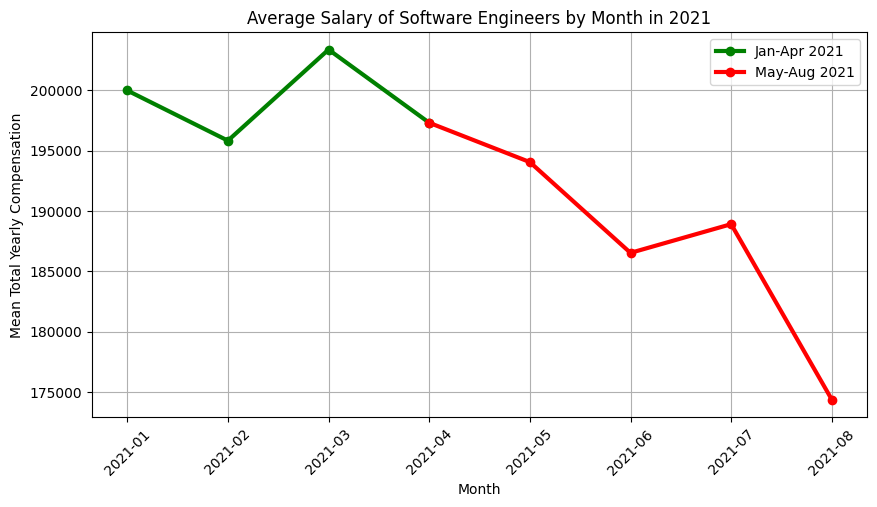

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel ('P01_Salaries_Dataset.xlsx')
df ['timestamp'] = pd.to_datetime (df['timestamp']) # превратили колонку timestamp из текста в колонку 
se_2021 = df [
    (df['title'] == 'Software Engineer') & 
    (df['timestamp'] >= '2021-01-01') &
    (df['timestamp'] < '2021-09-01')
    ].copy()
se_2021 ['month'] = se_2021['timestamp'].dt.to_period('M').astype(str) # создаем новую колонку month, dt.to_period('M') превращает дату в формат год-месяц .astype(str) это переводит результат в строку для удобного отображения на графике т.к. Matplotlib лучше работает со строками и удобнее отображать на графике
monthly_mean = ( # группируем по месяца и считаем среднюю зарплату по каждому месяцу
    se_2021
    .groupby('month')['totalyearlycompensation']
    .mean()
)
month_order = pd.period_range('2021-01', '2021-08', freq ='M').astype(str) # здесь создали список месяцев pd.period_range месяцы от января до августа 2021 freq ='M' с шагом - месяц автоматически 

monthly_mean = monthly_mean.reindex(month_order) # переупорядочиваем series monthly_mean по этому списку

plt.figure(figsize=(10,5)) # срздаем график и задаем размер рисунка

plt.plot( # строим первую часть линии янв-апрель зеленым цветом
    monthly_mean.index[:4], # взяли индексы месяцы с начала до 4-го, не включая 4-й
    monthly_mean.values[:4], #это средние первые 4 значения (зп) этих месяцев
    marker = 'o', # это маркер точек на линииб, т.е. на каждой точке линии будет кружочек
    color = 'green',
    linewidth = 3,
    label = 'Jan-Apr 2021'
)
plt.plot(
    monthly_mean.index[3:], # берем индекс 4 (это май) и до конца 
    monthly_mean.values[3:], # а это средние зп значения за эти месяцы с мая по август включительно
    marker = 'o',
    color = 'red',
    linewidth = 3,
    label = 'May-Aug 2021'
)
plt.title ('Average Salary of Software Engineers by Month in 2021')
plt.xlabel ('Month') # подписи осей
plt.ylabel ('Mean Total Yearly Compensation')
plt.xticks (rotation = 45) # поворачиваем подписи месяцев
plt.legend () # включаем легенду чтобы было видно какой цвет какому периоду соответствует
plt.grid (True) # добавляем сетку для удобства чтения графика 
plt.show()

8. Оцените влияние уровня образования (или его отсутствия) к заработной плате



In [ ]:
df.columns # смотрим колонки

Index(['Unnamed: 0', 'timestamp', 'company', 'level', 'title',
       'totalyearlycompensation', 'location', 'yearsofexperience',
       'yearsatcompany', 'tag', 'basesalary', 'stockgrantvalue', 'bonus',
       'gender', 'Race', 'Education'],
      dtype='object')

In [20]:
df['Education'].value_counts () # проверяем данные

Education
Master's Degree      17187
Bachelor's Degree    14070
PhD                   1892
Some College           404
Highschool             356
Name: count, dtype: int64

In [ ]:
education_salary = (
    df
    .groupby ('Education')['totalyearlycompensation'] # делим людей по образованию и для каждого берем зп(список зп)
    .agg (['count','mean','median']) # считаем сколько людей среднюю и медиану
    .sort_values('mean', ascending=False) #сортируем от самых высоких зп к самой низкой
    .reset_index() #добавила новые индексную строку 
)
education_salary

,Education,count,mean,median
0,PhD,1892,292860.465116,255000.0
1,Master's Degree,17187,220304.590679,195000.0
2,Some College,404,210747.524752,172500.0
3,Highschool,356,187741.573034,162000.0
4,Bachelor's Degree,14070,178092.821606,156000.0


In [ ]:
education_salary = education_salary.reset_index() # здесь попробовала по другому добавить новую идексную строку
education_salary

,Education,count,mean,median
0,PhD,1892,292860.465116,255000.0
1,Master's Degree,17187,220304.590679,195000.0
2,Some College,404,210747.524752,172500.0
3,Highschool,356,187741.573034,162000.0
4,Bachelor's Degree,14070,178092.821606,156000.0


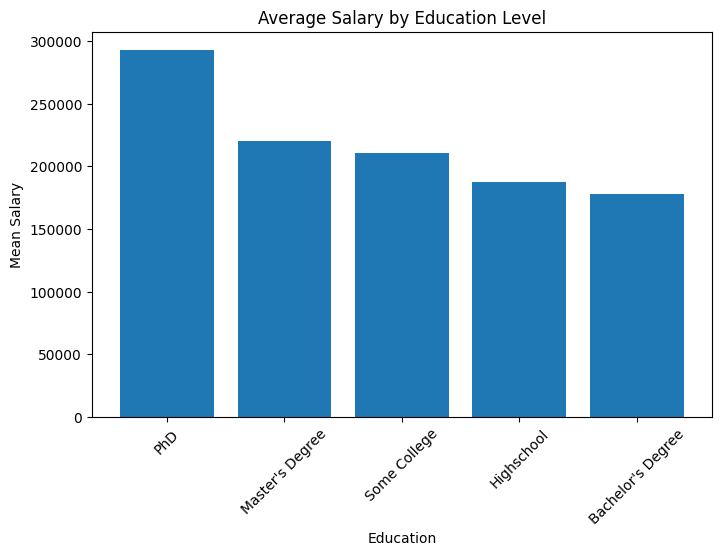

In [ ]:
import matplotlib.pyplot as plt # график средней зп

plt.figure (figsize = (8,5)) # создаем область для графика и задаем размер графика: ширина 8, высота 5

plt.bar(
    education_salary ['Education'], # ось х уровни образования
    education_salary['mean'] # ось у средняя зп
)
plt.title ('Average Salary by Education Level')
plt.xlabel ('Education')
plt.ylabel ('Mean Salary')

plt.xticks (rotation= 45) # поворачиваем подписи по оси х на 45 градусов, чтобы текст не накладывался друг на друга 
plt.show() 

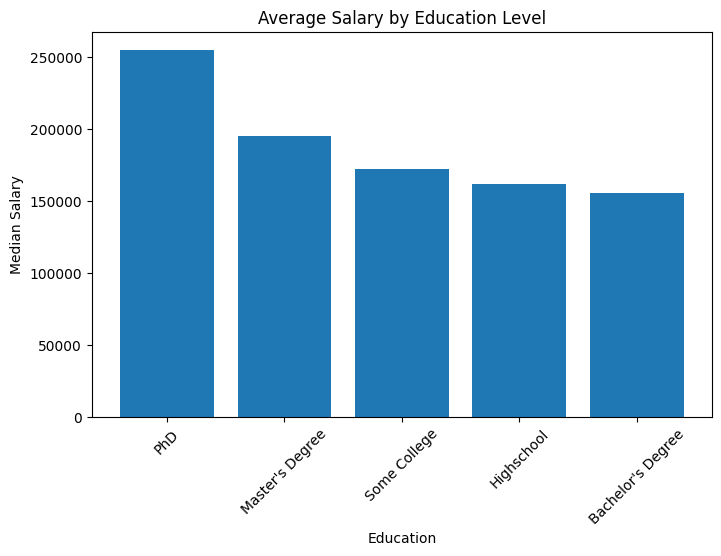

In [ ]:
import matplotlib.pyplot as plt # график мединной зп

plt.figure (figsize = (8,5))

plt.bar(
    education_salary ['Education'],
    education_salary['median']
)
plt.title ('Average Salary by Education Level')
plt.xlabel ('Education')
plt.ylabel ('Median Salary')

plt.xticks (rotation= 45)
plt.show() 

Анализ показал, что уровень образования связан с уровнем заработной платы. Самые высокие значения средней заработной платы наблюдаются у специалистов с уровнем PhD, что может быть связяно с высокой квалификацией, более сложными ролями и большим профессиональным опытом. 
Интересным наблюдением является то, что категория Bachelor's Degree показывает самые низкие значения средней зарплаты по сравнению с другими группами, уступая даже High School. Такой результат, возможно связан с составом выборки: количестово группы Bachelor составляет более 14 тыс человек и здесь могут быть больше специалистов начального уровня, тогда как в группе High School (около 400 чел.) могут находиться более опытные сотрудники или специалисты с редкими практическими навыками.  

9. Оцените _зависимость_ между опытом работы `yearsofexperience` и заработной платой



In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('P01_Salaries_Dataset.xlsx')
exp_salary = df[['yearsofexperience', 'totalyearlycompensation']].copy() # оставляем только две нужные колонки опыт работы и годовую компенсацию  
exp_salary = exp_salary.dropna() # удаляем строки, где есть пропуски. это нужно, чтобы корреляция и график считались конкретно
spearman_corr = exp_salary ['yearsofexperience'].corr(
    exp_salary['totalyearlycompensation'], # считаем корреляцию спирмана между опытом и зп; корреляция показывает, насколько сильно две переменные связаны 
    method= 'spearman'
)

print ('Spearman correlation:', round (spearman_corr, 3))

Spearman correlation: 0.457


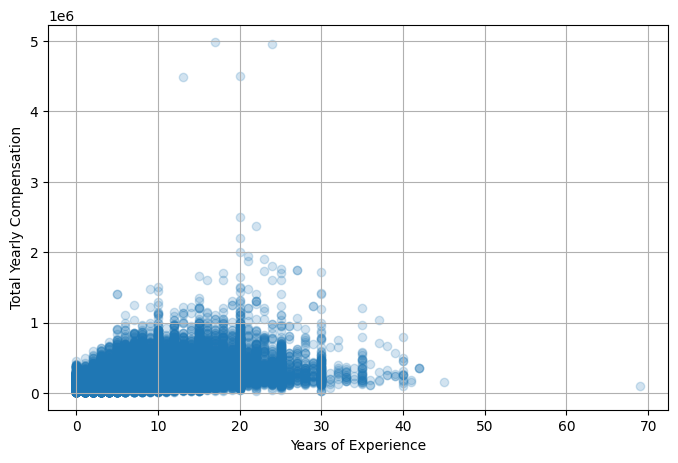

In [33]:
plt.figure (figsize= (8,5))
plt.scatter (
    exp_salary ['yearsofexperience'],
    exp_salary['totalyearlycompensation'],
    alpha=0.2 # делает точки полупрозрачными, чтобы график был читаемее
)
plt.xlabel ('Years of Experience')
plt.ylabel('Total Yearly Compensation')
plt.grid(True)
plt.show()

  Анализ показал наличие умеренной положительной зависимости между опытом работы и уровнем заработной платы. Значение корреляции Пирсона указывает на наличие линейной связи между двумя переменными - опытом и зарплатой, однако эта связь не является сильной и идеальной. В целом можно сделать вывод, что чем выше опыт работы, тем выше заработная плата. 
  Дополнительно был проведен анализ по Спирману, так как наблюдаются выбросы, рост зарплаты нестабилен, при одинаковом опыте наблюдается значительный разброс заработной платы, а у части специалистов после 30-40 лет опыта рост зарплаты практически останавливается. Зависимость не выглядит идеально линейной.
  Корреляция Спирмана также показала умеренно положительную монотонную связь. 


10. Сделайте сравнение уровня зарплат в зависимости от грэйда (level) в компании Amazon на позицию 'Software Engineer'. Постройте визуализацию и **напишите ваши выводы**. [Подробнее о грэйдах в Amazon](https://careerkarma.com/blog/software-engineering-salary-amazon/), [примеры исследования позиций и зарплат в Казахстане](https://zerttey.kolesa.group/datascience#zp)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('P01_Salaries_Dataset.xlsx')
amazon_df = df[ # фильтруем данные 
    (df['company'] == 'Amazon') & 
    (df['title'] == 'Software Engineer')          
].copy()
amazon_df = amazon_df.dropna(subset=['level', 'totalyearlycompensation'])
level_salary = (
    amazon_df
    .groupby ('level')['totalyearlycompensation']
    .agg (['count', 'mean', 'median'])
    .sort_index()

)
level_salary

,count,mean,median
level,,,
L4,1591,150054.682590,156000.0
L5,2147,210082.440615,215000.0
L6,579,304937.823834,300000.0
SDE I,463,151063.714903,156000.0
SDE II,447,209071.588367,210000.0
SDE III,103,305543.689320,300000.0


In [16]:
level_salary = (
    amazon_df
    .groupby ('level')['totalyearlycompensation'] # делим людей по образованию и для каждого берем зп(список зп)
    .agg (['count','mean','median']) # считаем сколько людей среднюю и медиану
    .sort_index()
    .reset_index()
)
level_salary

,level,count,mean,median
0,L4,1591,150054.682590,156000.0
1,L5,2147,210082.440615,215000.0
2,L6,579,304937.823834,300000.0
3,SDE I,463,151063.714903,156000.0
4,SDE II,447,209071.588367,210000.0
5,SDE III,103,305543.689320,300000.0


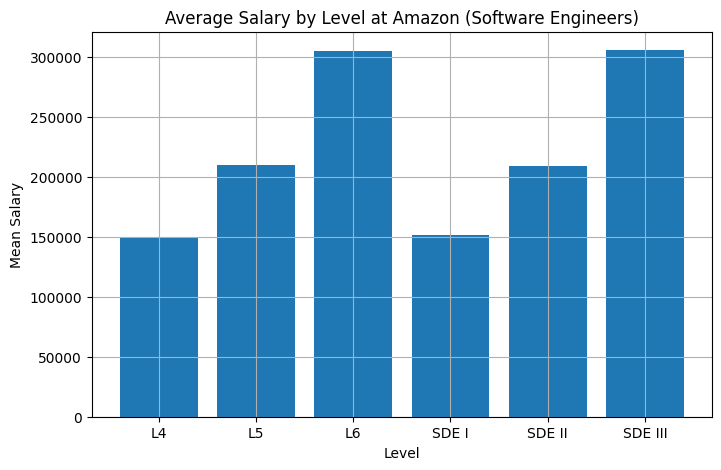

In [17]:
plt.figure(figsize=(8,5))

plt.bar (level_salary ['level'], level_salary ['mean'])
plt.title ('Average Salary by Level at Amazon (Software Engineers)')
plt.xlabel ('Level')
plt.ylabel('Mean Salary')
plt.grid(True)
plt.show()


По результатам анализа видна зависимость параметров. С ростом левела зарплата увеличивается, что подтверждает влияние карьерного уровня на доход.
Также увидели в датасете разные варианты обозначения одного левела, но по сути это одно и тоже. 